# Week-6: Narrowband Frequency Modulation
In this week's lab we will see **Narrow Band Frequency Modulation (NBFM)**. Concepts in previous AM Lab like finding frequencies, converting signal to baseband, decimation apply here, too. However decoding method is different as we will see.   

## Frequency Modulation
In FM, information that we would like to send is encoded in **frequency** of carrier. This is different from AM where amplitude of carrier is used to transfer information. FM is more **resistant** to propagation so it is preffered over AM for voice transmission. That's why it is commonly used for V/UHF handhelds where audio waveform is sent using carrier frequency. In FM communication, carrier will be always on. This is bad in terms of power consumption but as we said it is more resistant to channel effects. 

## Handheld Radios
Handheld radios use NBFM to send audio data to the other side. They usually operate in VHF or UHF bands. Literally, 
* 144-148 MHz in VHF band (2m band)
* 420-450 MHz in UHF band (70cm band)

Most radios operate both in VHF and UHF bands. They always have FM voice and may have digital voice. 

##  Walkthrough Example
In this week's repo you will find `rtl_nbfm.dat` file which is a capture of **2.048MHz** of the RF spectrum centered at **145.5 MHz**. First let's find out what our IQ record is like. 

In [3]:
import os
file_name = 'rtl_nbfm.dat'
number_of_samples = os.path.getsize(file_name) / 2
print("Record contains " + str(int(number_of_samples)) + " complex samples and this corresponds to " + str(number_of_samples / 2048000) + " seconds data. ")

Record contains 20480000 complex samples and this corresponds to 10.0 seconds data. 


We will be again using the same RTL record loader from the previous lab. 

In [5]:
def RTLSDRLoadRecord(file_name):
    import numpy as np
    data = np.fromfile(file_name, np.uint8)
    # change it to complex data
    data_c = data[::2] + 1j * data[1::2]
    # remove offset
    return data_c - (128 + 1j * 128)

Use this function to **read** samples. 

In [3]:
data = RTLSDRLoadRecord('rtl_nbfm.dat');

Use **spectrogram** to view frequency content. 

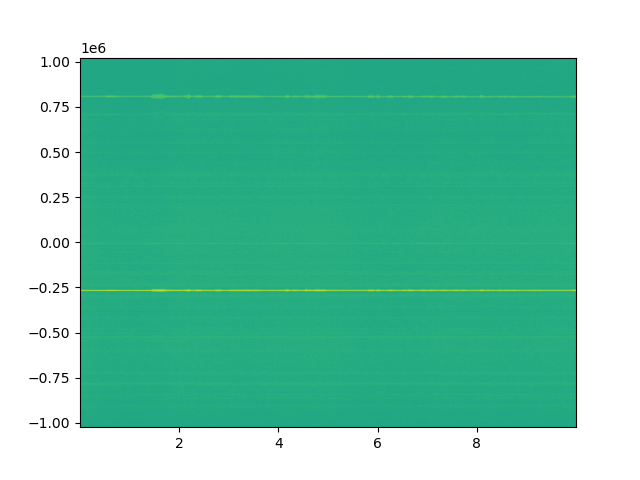

In [4]:
import matplotlib.pyplot as plt
%matplotlib widget
sp = plt.specgram(x=data, Fs=2048000, NFFT=2048)

Another good utility to see frequency content is to use **Power Spectral Density (PSD)** graph. 

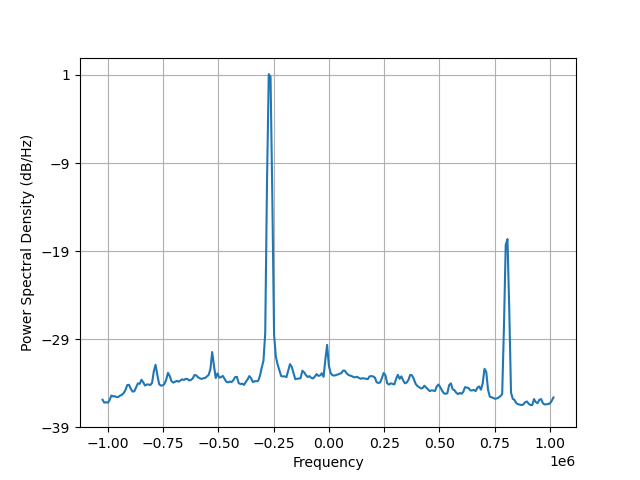

In [5]:
plt.figure()
psd = plt.psd(x=data, Fs=2048000)

Our signal of interest seems to be at -270kHz. So we first **shift** it so it appears at the center. 

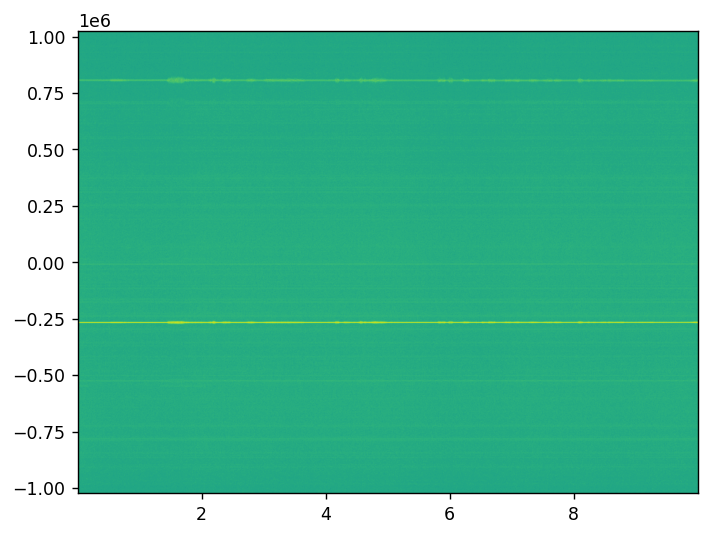

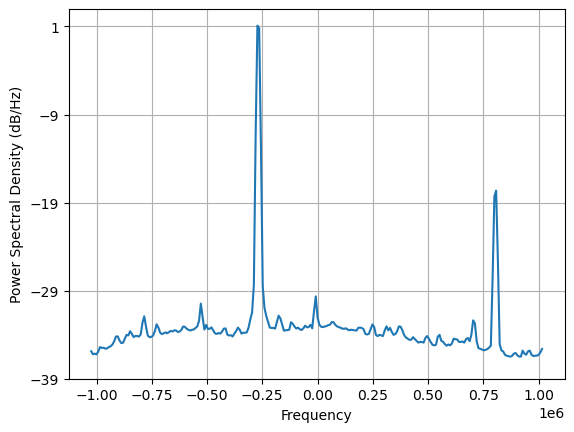

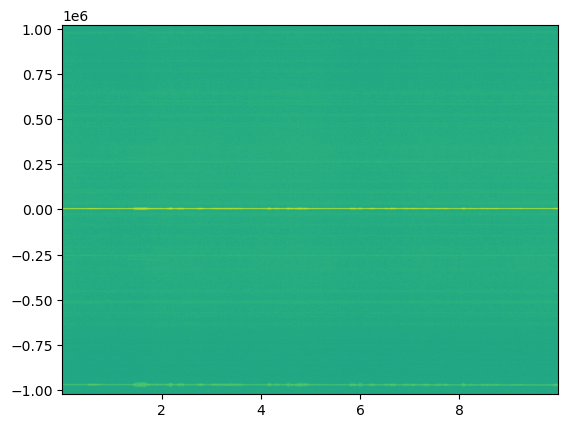

In [6]:
%matplotlib inline
import numpy as np
Fs = 2048000;
dt = 1 / Fs;
t = np.r_[:10:dt]
data_center = data * np.exp(1j*2*np.pi*(270000)*t);
plt.figure()
sp = plt.specgram(x=data_center, Fs=2048000, NFFT=2048)

Our signal of interest is only a few kHz, so **decimate** by 64. 

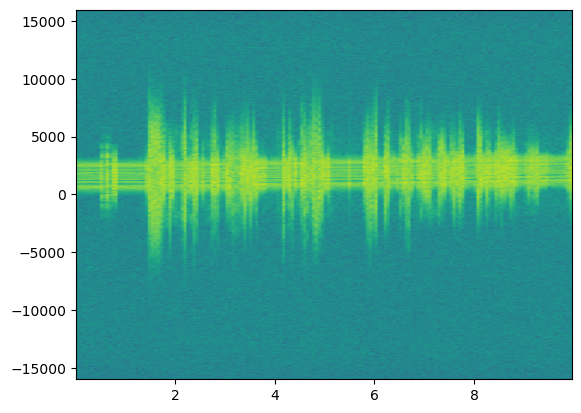

In [7]:
# Then decimate it by an amount to play it with our sound card. 
from scipy import signal
data_dec = signal.decimate(data_center, 64, ftype='fir')
sp = plt.specgram(x=data_dec, Fs=32000, NFFT=2048)

**Demodulate NBFM** data and play it. 

In [8]:
# normalize data before sending
import sounddevice as sd
data_demod = np.angle(np.conj(data_dec[0:-1])*data_dec[1:])
max_val=np.max(np.abs(data_demod))
data_demod = data_demod / max_val
print(len(data_demod))
sd.play(data_demod, 32000)
status = sd.wait()  # Wait until file is done playing

319999


### Capturing IQ data 
You can capture IQ data using `rtl_sdr` application. If you are outside or near to window you will get better result in demodulation. If you opt to capture your own signal make sure you have applied gain suitable to receive correctly. You can use rtl_test to list available gains. You can set gain by using -g switch for rtl_sdr. 

### Example use
This is just a reminder on how to take record using **rtl_sdr**. Suppose  you want to set SDR to your favorite station's frequency and capture 10 seconds of IQ data. For example to capture 10 seconds of IQ data sampled at 1.024MSPS from TRT FM radio station use an **example command** like below. 
```
rtl_sdr -f 88000000 -s 1024000 -n 10240000 wbfm88_10s.dat
``` 
This will put samples into a file called `wbfm88_10s.dat` in your current folder. Do not forget to delete it afterwards!

In [9]:
!rtl_sdr -f 88000000 -s 1024000 -n 10240000 wbfm88_10s.dat

No supported devices found.


# Task-1

## Q1: Write a complete NBFM decoder function for RTL-SDR record (10pts)

Package up what we have done to demodulate NBFM signal into a Python function, named `nbfm_decoder.m`. You would use it like below. **It will take two params, record file name and frequency shift and will return 48kHz NBFM demodulated data**. 
```
sound(nbfm_decoder('rtl_nbfm.dat', -270000), 48000)
```

In [1]:
from scipy import signal
def nbfm_decoder(file_name, center_frequency):
    number_of_samples = os.path.getsize(file_name) / 2
    data = RTLSDRLoadRecord(file_name)
    Fs = 2048000
    dt = 1 / Fs
    t = np.r_[:10:dt]
    data_center = data * np.exp(1j*2*np.pi*(-center_frequency)*t)
    data_dec = signal.decimate(data_center, 42, ftype='fir')
    data_demod = np.angle(np.conj(data_dec[0:-1])*data_dec[1:])
    max_val=np.max(np.abs(data_demod))
    data_demod = data_demod / max_val
    return data_demod

## Q2: Test your function (10pts)
Use your `nbfm_decoder` function to test it. Make sure you hear human voice! Create a wav file named `nbfm.wav` using your function.  

In [68]:
# test with the example frequency = -270000
sd.play(nbfm_decoder('rtl_nbfm.dat', -270000), 48000)
write('nbfm.wav', 48000, nbfm_decoder('rtl_nbfm.dat', -270000).astype(np.float32))

## Q3: What is the real RF frequency of this signal?  (10pts)

A3: 145.23 Mhz


## Q4: Two tones (20pts)
There are two short segments of constant frequency at the beginning of the signal. What are the frequencies of these tones? 

**Hint**: try spectrogram of the decoded signal. 

A4: As we see in the graph below, we get 531 Hz and 783 Hz frequency tones. The other 100 Hz is hum.

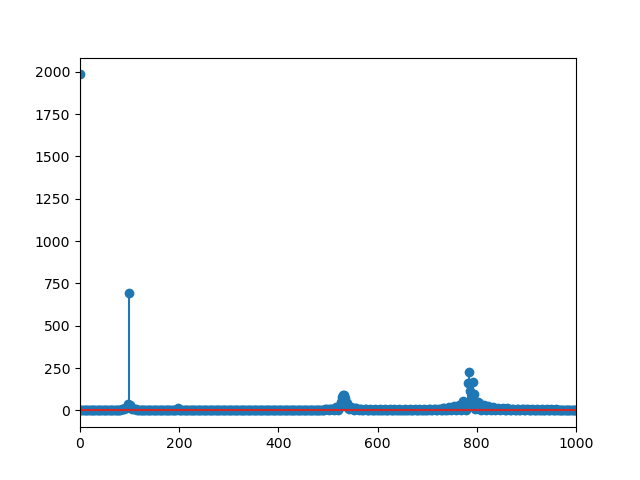

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
plt.figure()
x = nbfm_decoder('rtl_nbfm.dat', -270000)[25000:45000]#we just have the data at the beginning by using slicing
L = len(x)
Fs = 48000 
fft_values = np.fft.fft(x)
array = np.linspace(0,Fs, L)
plt.stem(array,abs(fft_values))
plt.xlim(0,1000)
plt.show()

## Q5: CTCSS Frequency (20 pts)
You should also hear a background hum in addition to some human voice. What is the frequecy of this sub-audible tone? 

Note: This is called CTCSS tone. 

A5: As seen in the graph above, we have hum at 100 Hz.

## Q6: What is frequency range for CTCSS and what is it used for? (20pts)

A6:The range of CTCSS is from 67 Hz to 254.1 Hz.It is used to reduce interference on shared communication channels. Especially it is used in amateur  radio telecommunications. 



# Task-2
Finish this task in colloboration with your instructor. Your instructor will transmit **call tone** from Motorola handheld radio. Make sure your record contains a right call tone signal! 

## Q1: Now tune to 462 MHz with a sampling rate of 2.048MSPS to record 10 seconds of data. Save your record file named `rtl_motorola.dat`. (10pts)

rtl_sdr -f 462564400 -s 2048000 -n 20480000 rtl_motorola.dat

## Q2: Plot the spectrogram and PSD of the signal you recorded above. (10pts)

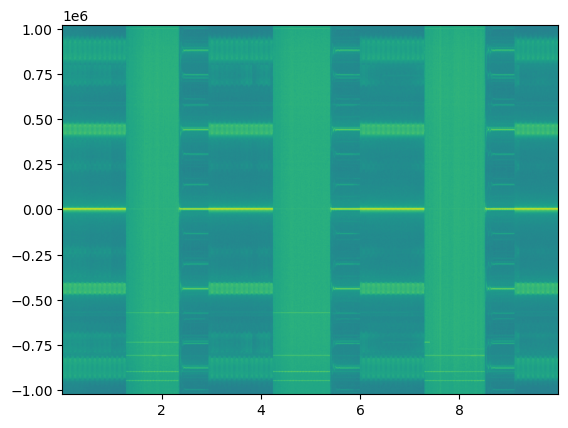

In [13]:
# spectrogram
data1 = RTLSDRLoadRecord('rtl_motorola.dat')
sp1 = plt.specgram(x=data1, Fs=2048000, NFFT=2048)
plt.show()

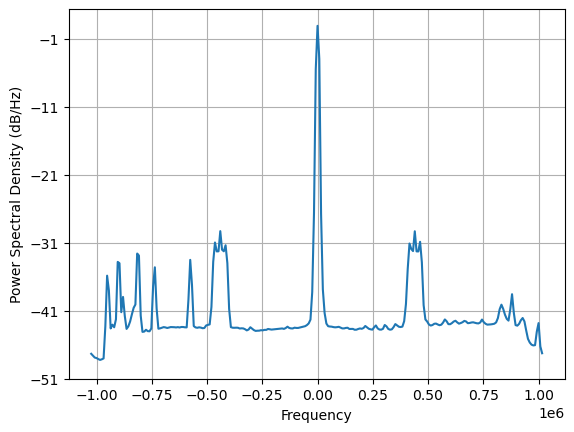

In [19]:
# PSD
plt.figure()
psd = plt.psd(x=data1, Fs=2048000)

## Q3: Demodulate and save your resulting sound data as wav file named `motorola.wav` (10pts)

In [23]:
# demodulation
from scipy.io.wavfile import write
demodulated_signal=nbfm_decoder('rtl_motorola.dat', 0)
write('motorala.wav', 48000, demodulated_signal.astype(np.float32))

## Q4: How many pulses are there in the tone call? (10pts)
**Hint**: Analyze sound data with `signal.spectrogram` function!

Before each noise we count 13 pulses and at the end we have 8 pulses. So totaly, we had 47 pulses.

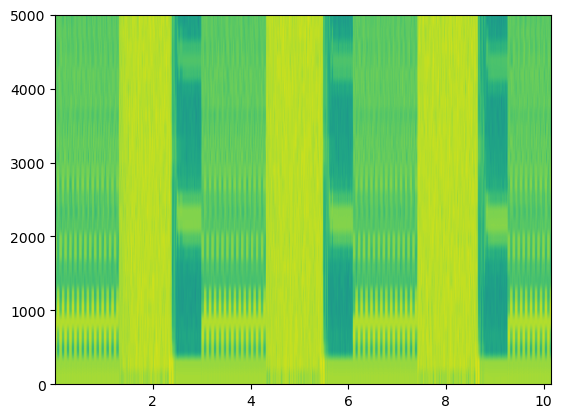

In [52]:
sp2 = plt.specgram(x=demodulated_signal, Fs=48000)
plt.ylim(0, 5000)
plt.show()

## Q5: What are the frequencies of the pulses? (10pts)

A5: As wee see in the specgram graph above pulses are located at 825 Hz